# 3. The copy that stays

**Week 1, Wednesday. Chapter 3 of 6.** Chapter 2 fixed the identity rule: an order is its order_id, and 15 orders appear twice. This chapter chooses which copy of each pair stays, and logs the other.

> **The client asks.** "Your dashboard says Q1 was Rs 2.1 crore. Our books say 1.9. Until your
> numbers match ours, Finance will not act on a drop measured from an ERP export. Send me a
> reconciliation."
>
> Anand Iyer, finance controller, Kalpa Retail

**The need.** Fifteen orders appear twice. For thirteen the two copies are identical and either may
stay; for two they disagree, and the choice moves Q1 and a delivery date. Anand's analyst ties out
to the rupee, so a choice that loses one order's amount turns a reconciliation into a finding
against the team.

**Who else faces it.** India's GST system writes the identity rule into law for every business invoice. The Invoice Registration Portal rejects an invoice already reported under the same supplier GSTIN (its GST registration number), invoice number, document type and financial year, the fields it also hashes into the invoice's reference number (GSTN e-invoice FAQ, version 1.4, checked 30 Sep 2026). Since 1 August 2023 that applies to every business above Rs 5 crore of turnover (Notification 10/2023-Central Tax, checked 30 Sep 2026), which includes a seller like Kalpa's Business segment.

Kalpa Retail's business, its metrics and who decides what are in the retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`; this notebook assumes it.

**Setup.** The helper, chapter 1's tools and the identity rule this chapter builds, defined once so later chapters reuse it.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter
from datetime import date

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

FIELDS = ["order_id", "customer_id", "segment", "channel", "city", "order_date", "amount",
          "status", "quarter", "discount"]
NUMERIC = {"amount", "discount"}

def profile(rows, fields=FIELDS):
    """Per field: present, convertible where the field is a number, and distinct."""
    out = {}
    for f in fields:
        present = [r.get(f, "") for r in rows if r.get(f, "") not in ("", None)]
        ok = [v for v in present if convert(v)[0] is not None] if f in NUMERIC else present
        out[f] = {"present": len(present), "convertible": len(ok), "distinct": len(set(present))}
    return out

def identity_rule(rows, key="order_id"):
    """One row per order: the first copy whose amount converts stays, and every other row is logged."""
    groups = {}
    for r in rows:
        groups.setdefault(r[key], []).append(r)
    kept, log = [], []
    for k, rs in groups.items():
        valid = [r for r in rs if convert(r["amount"])[0] is not None]
        keep = (valid or rs)[0]
        kept.append(keep)
        for r in rs:
            if r is keep:
                continue
            differs = [f for f in r if f != "line" and r[f] != keep[f]]
            reason = ("copy whose amount does not convert; its twin carries the value"
                      if convert(r["amount"])[0] is None else "second copy of the order")
            if differs and "amount" not in differs:
                reason += "; differs on " + ", ".join(differs)
            log.append({"line": r["line"], "order_id": k, "quarter": r["quarter"], "segment": r["segment"],
                        "amount": r["amount"], "rule": key, "reason": reason, "kept_line": keep["line"]})
    return kept, log

raw = read_orders()
print(len(raw), "rows read")

201 rows read


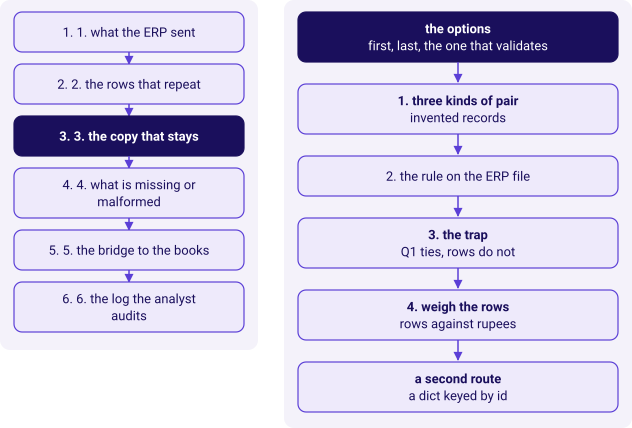

In [2]:
kit.side_by_side(
    kit.ladder(["1. what the ERP sent", "2. the rows that repeat", "3. the copy that stays", "4. what is missing or malformed", "5. the bridge to the books", "6. the log the analyst audits"], lit=2, show=False),
    kit.vflow(["the options\nfirst, last, the one that validates", "1. three kinds of pair\ninvented records", "2. the rule on the ERP file", "3. the trap\nQ1 ties, rows do not", "4. weigh the rows\nrows against rupees", "a second route\na dict keyed by id"], lit=0, show=False),
)

## The options

| Option | Which copy stays | What it assumes |
|---|---|---|
| a) The first in the file | the row from the first extract | the first extract is the original |
| b) The last in the file | the row from the second extract | the second extract corrected the first |
| c) The copy that validates, then the first | a copy whose amount converts; the first if both do | a value beats no value; otherwise keep the original |
| d) Keep both, escalate every pair | none until the ERP team answers | nobody inside Kalpa can decide |

**Predict before you run.** Which options land Q1 on the books to the rupee? a) a only; b) b and c;
c) c only; d) all four.

option,Q1,against the books,unreadable orders kept,questions to the ERP team
a) first,"Rs 1,89,98,210","-Rs 1,790",1,none
b) last,"Rs 1,90,00,000",Rs 0,0,none
c) validates,"Rs 1,90,00,000",Rs 0,0,none
d) escalate all,open,open,0,"15 pairs, days of waiting"


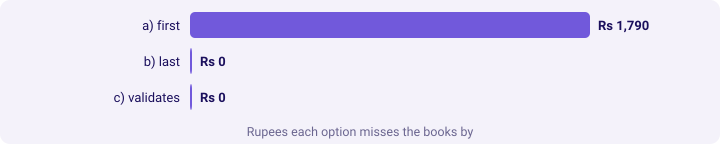

In [3]:
def keep(rows, how):
    kept = {}
    for r in rows:
        k = r["order_id"]
        if k not in kept or how == "last":
            kept[k] = r
        elif how == "validates" and convert(kept[k]["amount"])[0] is None and convert(r["amount"])[0] is not None:
            kept[k] = r
    return list(kept.values())

options = {"a) first": keep(raw, "first"), "b) last": keep(raw, "last"), "c) validates": keep(raw, "validates")}
rows_out = [(name, kit.rupees(Q(k, "Q1")), kit.rupees(Q(k, "Q1") - BOOKS_Q1),
             sum(1 for r in k if convert(r["amount"])[0] is None), "none") for name, k in options.items()]
rows_out.append(("d) escalate all", "open", "open", 0, "15 pairs, days of waiting"))
kit.table(["option", "Q1", "against the books", "unreadable orders kept", "questions to the ERP team"], rows_out,
          caption="Each option sized on the ERP file")
kit.bars([(n, abs(Q(k, "Q1") - BOOKS_Q1)) for n, k in options.items()], fmt=kit.rupees,
         title="Rupees each option misses the books by")

**What happened.** The answer is b. The first copy keeps a row whose amount cannot be read and lands
Rs 1,790 short. The last copy lands on the books, and the copy that validates lands on the books;
escalating everything leaves Q1 open for as long as the ERP team takes to answer 15 questions,
13 of which have no question in them.

**The best-fit call: c, and escalate only a pair whose valid copies disagree.** The last copy is
right here because of the order the migration appended its rows, which is luck rather than a rule.
**The fact that would change it:** the ERP team saying the second extract was a corrected re-run.
Then b is the rule, and it is right for a reason.

## 1. Three kinds of pair, on invented records

Pair A is an exact copy. In pair B one copy's amount does not convert and the other's does. In
pair C both convert and the two disagree on the date.

**Predict before you run.** For pair C, which copy should stay? a) the first, logged, and the date
asked of the ERP team; b) the later date; c) neither; d) both.

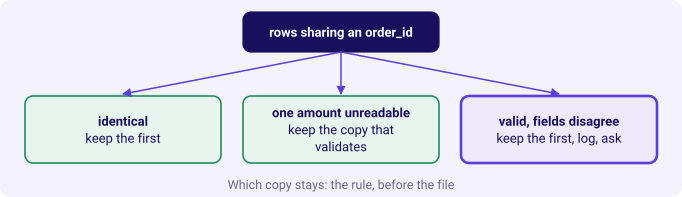

order,kept line,set aside,reason
INV-11,12,90,second copy of the order
INV-12,95,20,copy whose amount does not convert; its twin carries the value
INV-13,40,99,second copy of the order; differs on order_date


In [4]:
pairs = [
    {"order_id": "INV-11", "quarter": "Q1", "segment": "Retail-Core", "order_date": "2026-05-02", "amount": "1800", "line": 12},
    {"order_id": "INV-11", "quarter": "Q1", "segment": "Retail-Core", "order_date": "2026-05-02", "amount": "1800", "line": 90},
    {"order_id": "INV-12", "quarter": "Q1", "segment": "Retail-Plus", "order_date": "2026-05-14", "amount": "n/a", "line": 20},
    {"order_id": "INV-12", "quarter": "Q1", "segment": "Retail-Plus", "order_date": "2026-05-14", "amount": "2600", "line": 95},
    {"order_id": "INV-13", "quarter": "Q2", "segment": "Retail-Plus", "order_date": "2026-08-21", "amount": "3100", "line": 40},
    {"order_id": "INV-13", "quarter": "Q2", "segment": "Retail-Plus", "order_date": "2026-07-30", "amount": "3100", "line": 99},
]   # invented
kept_pairs, log_pairs = identity_rule(pairs)
kit.tree({"label": "rows sharing an order_id", "kind": "lit", "branches": [
    ("", {"label": "identical\nkeep the first", "kind": "good"}),
    ("", {"label": "one amount unreadable\nkeep the copy that validates", "kind": "good"}),
    ("", {"label": "valid, fields disagree\nkeep the first, log, ask", "kind": "known"})]},
    title="Which copy stays: the rule, before the file")
kit.table(["order", "kept line", "set aside", "reason"],
          [(e["order_id"], e["kept_line"], e["line"], e["reason"]) for e in log_pairs],
          caption="Invented pairs: one row per order, and a reason for every row set aside")
kit.check("the unreadable copy of INV-12 is the one set aside", [e["line"] for e in log_pairs if e["order_id"] == "INV-12"] == [20])

**What happened.** The answer is a. Keeping the first copy of pair B would keep the one that cannot
be summed, so the rule prefers the copy that validates. In pair C both copies are valid and no rule
inside the file can say which date is true, so the rule keeps the first extract's row, logs the
disagreement and turns the date into a written question for the ERP team.

## 2. The rule on the ERP file

**Predict before you run.** After the identity rule, Q1 is? a) Rs 2,09,98,210; b) Rs 1,89,98,210;
c) Rs 1,90,00,000; d) Rs 2,00,00,000.

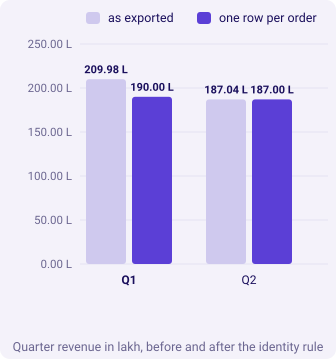

In [5]:
kept, set_aside = identity_rule(raw)
kit.columns(["Q1", "Q2"], [("as exported", [Q(raw, "Q1") / 1e5, Q(raw, "Q2") / 1e5]),
                           ("one row per order", [Q(kept, "Q1") / 1e5, Q(kept, "Q2") / 1e5])],
            fmt=lambda v: f"{v:,.2f} L", lit=(0,), title="Quarter revenue in lakh, before and after the identity rule")
kit.stats([(str(len(kept)), "orders kept", "one row per order_id"),
           (str(len(set_aside)), "rows set aside", "each with a reason"),
           (kit.rupees(Q(kept, "Q1")), "Q1", "the books say Rs 1,90,00,000")])
kit.check("186 orders kept and 15 rows set aside", (len(kept), len(set_aside)) == (186, 15))
kit.check("Q1 lands on the books", Q(kept, "Q1") == BOOKS_Q1, kit.rupees(Q(kept, "Q1")))
kit.check("no kept order has an amount that fails", all(convert(r["amount"])[0] is not None for r in kept))

**What happened.** The answer is c. Q1 moves from Rs 2,09,98,210 to Rs 1,90,00,000, Finance's 1.9
crore to the rupee, and Q2 from Rs 1,87,03,710 to Rs 1,87,00,000. The amount chapter 1 could not
read turned out to be one copy of a pair whose twin carries the value, so no revenue went with it.

**Your turn.** In the empty cell, print the log rows whose reason is more than "second copy of the
order": `[(e["line"], e["order_id"], e["reason"]) for e in set_aside if e["reason"] != "second copy of the order"]`.
For each, write the question you would send the ERP team.

## 3. The trap: Q1 ties to the books, so the pass must be right

Chapter 2 showed that leaving the line out of the whole record finds copies. The hurried analyst
does exactly that, sees Q1 land on the books, and stops.

**The plausible wrong answer.**

In [6]:
seen, exact = set(), []
for r in raw:
    k = tuple(sorted((f, v) for f, v in r.items() if f != "line"))
    if k not in seen:
        seen.add(k)
        exact.append(r)
kit.stats([(kit.rupees(Q(exact, "Q1")), "Q1", "equal to the books, to the rupee"),
           (str(len(exact)), "orders in the clean file", "reported as orders"),
           (kit.rupees(Q(exact, "Q2")), "Q2", "sent on to Marketing")],
          caption="The whole record less the line, as it would be reported")

**Why it is wrong.** Q1 ties because the two pairs this pass misses happen to cost Q1 nothing: one
copy's amount cannot be read, so it adds nothing to the sum. The file still holds 188 rows for 186
orders. One Q2 order is counted twice, so Q2 is Rs 3,710 high and the Retail-Plus Q2 order count
is one too many, and an order with an unreadable amount sits in the clean file as an order. A
rupee tie on one quarter proves that quarter's rupees; it cannot prove the rows. The check is the
one chapter 2 taught: rows kept against distinct ids.

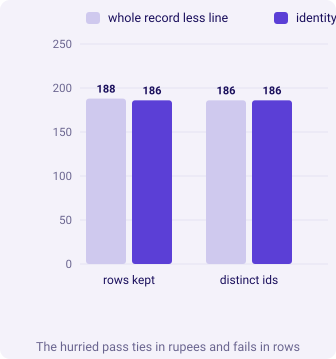

In [7]:
kit.check("the hurried pass keeps more rows than there are orders", len(exact) > len({r["order_id"] for r in exact}),
          f"{len(exact)} rows, {len({r['order_id'] for r in exact})} ids")
kit.check("the hurried Q2 is Rs 3,710 above one row per order", Q(exact, "Q2") - Q(kept, "Q2") == 3710)
kit.columns(["rows kept", "distinct ids"], [("whole record less line", [len(exact), len({r["order_id"] for r in exact})]),
                                           ("identity rule", [len(kept), len({r["order_id"] for r in kept})])],
            title="The hurried pass ties in rupees and fails in rows")

**The fix, and what changed.** The identity rule on `order_id`, preferring the copy that validates:
186 rows for 186 orders, Q2 down Rs 3,710 to Rs 1,87,00,000, the unreadable row set aside with its
reason, and one date written up as a question for the ERP team.

## 4. The harder variant: count the rows, weigh the rupees

**Predict before you run.** Of the Rs 19,98,210 the rule removed from Q1, what share sits in
Business rows? a) about a sixth, since they are 2 of 14; b) about half; c) nearly all; d) none.

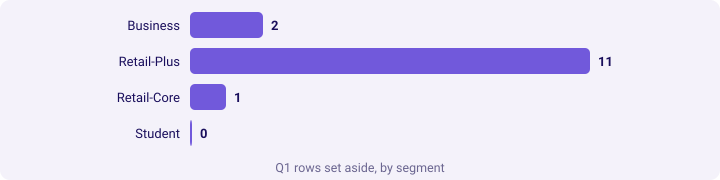

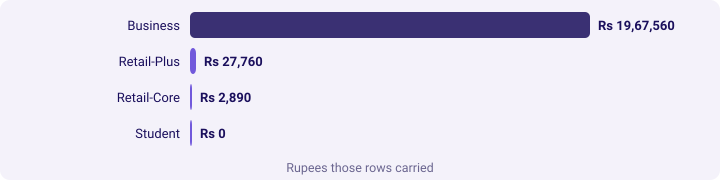

In [8]:
segs = ["Business", "Retail-Plus", "Retail-Core", "Student"]
q1_aside = [e for e in set_aside if e["quarter"] == "Q1"]
rows_removed = [sum(1 for e in q1_aside if e["segment"] == s) for s in segs]
rupees_removed = [sum(convert(e["amount"])[0] or 0 for e in q1_aside if e["segment"] == s) for s in segs]
kit.bars(list(zip(segs, rows_removed)), title="Q1 rows set aside, by segment")
kit.bars(list(zip(segs, rupees_removed)), fmt=kit.rupees, lit=(0,), title="Rupees those rows carried")
share = rupees_removed[0] / sum(rupees_removed)
kit.check("Business rows carry over 95 percent of the rupees removed", share > 0.95, f"{share:.1%}")
kit.check("Retail-Plus carries the most rows removed", rows_removed[1] == max(rows_removed), f"{rows_removed[1]} of {len(q1_aside)}")

**What happened.** The answer is c. Two Business rows carry Rs 19,67,560 of Rs 19,98,210, about 98
percent, and eleven Retail-Plus rows carry Rs 27,760. That split decides two conversations. Anand's
gap is two corporate orders counted twice. Tuesday's finding is a different matter: most extra rows
sit in Retail-Plus in Q1, the segment and quarter Tuesday compared, so its fall in orders per
customer was measured on inflated Q1 counts. Chapter 5 recomputes it.

## A second route: a dict keyed by id

A dictionary keeps one value per key, so building one from the valid rows is an identity rule in a
line. It keeps the last valid copy, and it logs nothing.

In [9]:
by_id = {r["order_id"]: r for r in raw if convert(r["amount"])[0] is not None}
same_ids = set(by_id) == {r["order_id"] for r in kept}
same_amounts = all(convert(by_id[r["order_id"]]["amount"])[0] == convert(r["amount"])[0] for r in kept)
kit.table(["route", "orders", "Q1", "Q2", "rows logged"],
          [("identity_rule", len(kept), kit.rupees(Q(kept, "Q1")), kit.rupees(Q(kept, "Q2")), len(set_aside)),
           ("a dict keyed by id", len(by_id), kit.rupees(Q(by_id.values(), "Q1")), kit.rupees(Q(by_id.values(), "Q2")), 0)])
kit.check("both routes keep the same 186 orders at the same amounts", same_ids and same_amounts)

route,orders,Q1,Q2,rows logged
identity_rule,186,"Rs 1,90,00,000","Rs 1,87,00,000",15
a dict keyed by id,186,"Rs 1,90,00,000","Rs 1,87,00,000",0


**When to switch.** The dict is the fast check that the rule's totals are right. It is never the
pass itself, since it chooses silently and leaves Anand's analyst nothing to audit.

> **Kavya's review.** "An identity rule, a preference for the copy that validates, and a reason on
> every row you set aside. And when Q1 ties to the books, check the rows before you celebrate."

### In the interview

**[F] Two copies of an order disagree. Which do you keep?** "The one whose fields validate; if
both do, the one the business calls the original, and I log the disagreement and ask the owner
of the source. I size the choice first: here keeping the first copy would have cost Rs 1,790."

**Design. First copy, last copy or the one that validates?** "The copy that validates, then the
first, with every set-aside row logged. Last copy happened to land on the books here, by file
order. If the ERP team told me the second extract was a corrected re-run, I would switch to last
and write that down as the reason."

### Depth: survivorship in a dedupe

Every "keep one" rule is a choice about which record survives, and each survivor rule carries an
assumption about the source: first means original, last means corrected, most complete means the
fields are independent. Master-data tools call this the survivorship rule, and they ask for it to
be written down per field.

In [10]:
kit.check_summary()
print("Next: chapter 4 decides what to do with values that are missing or cannot be read.")

Next: chapter 4 decides what to do with values that are missing or cannot be read.
